In [1]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv("/content/tmdb_5000_movies.csv")


print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (4803, 20)

First 5 rows:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [12]:
df = pd.read_csv("/content/tmdb_5000_credits.csv", engine='python')


print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (4803, 4)

First 5 rows:


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [19]:
import kagglehub

movies = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "tmdb/tmdb-movie-metadata",
    "tmdb_5000_movies.csv"
)

print("Original Dataset Shape:", movies.shape)

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Original Dataset Shape: (4803, 20)


In [43]:
print('Re-loading movies DataFrame and re-applying preprocessing steps to ensure correct genre parsing...')

import kagglehub
import pandas as pd
import numpy as np
import ast

movies = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "tmdb/tmdb-movie-metadata",
    "tmdb_5000_movies.csv"
)

# Re-apply NaN filling for numerical columns
num_columns = [
    'budget',
    'popularity',
    'revenue',
    'runtime',
    'vote_average',
    'vote_count'
]
for column in num_columns:
    movies[column] = movies[column].fillna(movies[column].median())

# Re-apply NaN filling for text columns
text_columns = [
    'genres',
    'keywords',
    'overview',
    'original_language',
    'tagline',
    'title'
]
for column in text_columns:
    movies[column] = movies[column].fillna("Unknown")

# Re-convert release_date
movies['release_date'] = pd.to_datetime(
    movies['release_date'],
    errors='coerce'
)
movies['release_date'] = movies['release_date'].fillna(
    pd.Timestamp('1900-01-01')
)

# Drop duplicates
movies = movies.drop_duplicates(subset='id').reset_index(drop=True)

# Reduce to top 200 movies
movies = movies.sort_values(by='popularity', ascending=False).head(200).reset_index(drop=True)

# Define and re-apply get_names function
def get_names(text):
    try:
        data = ast.literal_eval(text)
        return " ".join(
            item['name']
            for item in data
            if 'name' in item
        )
    except:
        return ""

movies['genres'] = movies['genres'].apply(get_names)
movies['keywords'] = movies['keywords'].apply(get_names)

# Re-create 'tags' column
movies['tags'] = (
    movies['genres'] + " " +
    movies['keywords'] + " " +
    movies['overview'] + " " +
    movies['original_language'] + " " +
    movies['tagline']
)

print('Data preparation complete. Displaying head of processed movies DataFrame:')
display(movies.head())

Re-loading movies DataFrame and re-applying preprocessing steps to ensure correct genre parsing...
Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Data preparation complete. Displaying head of processed movies DataFrame:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,tags
0,74000000,Family Animation Adventure Comedy,http://www.minionsmovie.com/,211672,assistant aftercreditsstinger duringcreditssti...,en,Minions,"Minions Stuart, Kevin and Bob are recruited by...",875.581305,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...",...,2015-06-17,1156730962,91.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Before Gru, they had a history of bad bosses",Minions,6.4,4571,Family Animation Adventure Comedy assistant af...
1,165000000,Adventure Drama Science Fiction,http://www.interstellarmovie.net/,157336,saving the world artificial intelligence fathe...,en,Interstellar,Interstellar chronicles the adventures of a gr...,724.247784,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",...,2014-11-05,675120017,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Mankind was born on Earth. It was never meant ...,Interstellar,8.1,10867,Adventure Drama Science Fiction saving the wor...
2,58000000,Action Adventure Comedy,http://www.foxmovies.com/movies/deadpool,293660,anti hero mercenary marvel comic superhero bas...,en,Deadpool,Deadpool tells the origin story of former Spec...,514.569956,"[{""name"": ""Twentieth Century Fox Film Corporat...",...,2016-02-09,783112979,108.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Witness the beginning of a happy ending,Deadpool,7.4,10995,Action Adventure Comedy anti hero mercenary ma...
3,170000000,Action Science Fiction Adventure,http://marvel.com/guardians,118340,marvel comic spaceship space outer space orpha...,en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",481.098624,"[{""name"": ""Marvel Studios"", ""id"": 420}, {""name...",...,2014-07-30,773328629,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,All heroes start somewhere.,Guardians of the Galaxy,7.9,9742,Action Science Fiction Adventure marvel comic ...
4,150000000,Action Adventure Science Fiction Thriller,http://www.madmaxmovie.com/,76341,future chase post-apocalyptic dystopia austral...,en,Mad Max: Fury Road,An apocalyptic story set in the furthest reach...,434.278564,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",...,2015-05-13,378858340,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,What a Lovely Day.,Mad Max: Fury Road,7.2,9427,Action Adventure Science Fiction Thriller futu...


Now that the `movies` DataFrame is correctly processed with parsed genre names, let's re-generate the 'Revenue by Genre' bar chart.

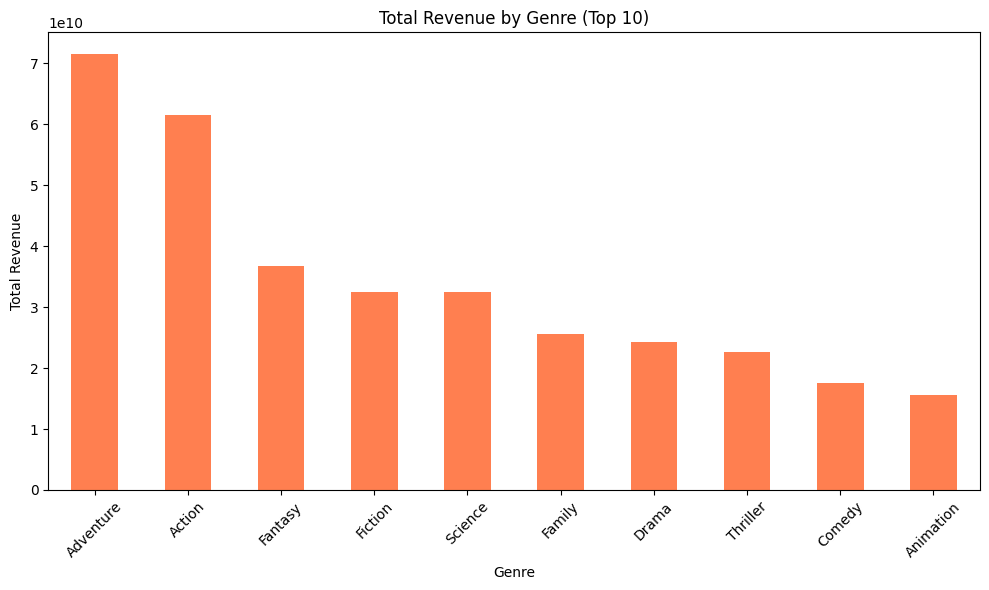

In [44]:
import matplotlib.pyplot as plt

genre_revenue = {}
for genres_str, rev in zip(movies['genres'], movies['revenue']):
    for genre in str(genres_str).split():
        genre_revenue[genre] = genre_revenue.get(genre, 0) + rev

genre_series = pd.Series(genre_revenue).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
genre_series.plot(kind='bar', color='coral')
plt.title("Total Revenue by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
print("\nNaN values before cleaning:")
print(movies.isnull().sum())


NaN values before cleaning:
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64


In [21]:
num_columns = [
    'budget',
    'popularity',
    'revenue',
    'runtime',
    'vote_average',
    'vote_count'
]

for column in num_columns:
    movies[column] = movies[column].fillna(
        movies[column].median()
    )

text_columns = [
    'genres',
    'keywords',
    'overview',
    'original_language',
    'tagline',
    'title'
]

for column in text_columns:
    movies[column] = movies[column].fillna("Unknown")

movies['release_date'] = pd.to_datetime(
    movies['release_date'],
    errors='coerce'
)

movies['release_date'] = movies['release_date'].fillna(
    pd.Timestamp('1900-01-01')
)




In [22]:
movies = movies.drop_duplicates(
    subset='id'
).reset_index(drop=True)

In [23]:
movies = movies.sort_values(
    by='popularity', ascending=False
).head(200).reset_index(drop=True)

print("\nDataset reduced to 200 rows. Shape now:", movies.shape)


Dataset reduced to 200 rows. Shape now: (200, 20)


In [42]:
import ast

def get_names(text):
    try:
        data = ast.literal_eval(text)
        return " ".join(
            item['name']
            for item in data
            if 'name' in item
        )
    except:
        return ""


movies['genres'] = movies['genres'].apply(get_names)
movies['keywords'] = movies['keywords'].apply(get_names)

In [26]:
movies['tags'] = (
    movies['genres'] + " " +
    movies['keywords'] + " " +
    movies['overview'] + " " +
    movies['original_language'] + " " +
    movies['tagline'])

In [27]:
print("\nNaN values after cleaning:")
print(movies.isnull().sum().sum())

print("\nDataset cleaned and reduced successfully!")
print("Final Dataset Shape:", movies.shape)




NaN values after cleaning:
37

Dataset cleaned and reduced successfully!
Final Dataset Shape: (200, 21)


In [29]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
vectors = vectorizer.fit_transform(movies['tags'])

In [31]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(vectors)

In [32]:
def recommend(movie_name):
    movie_name = movie_name.lower()

    movie_index = movies[
        movies['title'].str.lower() == movie_name
    ].index

    if len(movie_index) == 0:
        print("Movie not found!")
        return

    movie_index = movie_index[0]

    scores = list(enumerate(similarity[movie_index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print("\nMovies recommended for:", movies.iloc[movie_index]['title'])
    print("--------------------------------")

    for i, score in scores[1:11]:
        print(movies.iloc[i]['title'], " - Similarity:", round(score, 2))

In [33]:
movie_name = input("\nEnter a movie name: ")
recommend(movie_name)


Enter a movie name: Avengers
Movie not found!


In [34]:
movies.to_csv(
    "cleaned_movie_dataset_200.csv",
    index=False
)

print("\nCleaned dataset (200 rows) saved as:")
print("cleaned_movie_dataset_200.csv")



Cleaned dataset (200 rows) saved as:
cleaned_movie_dataset_200.csv


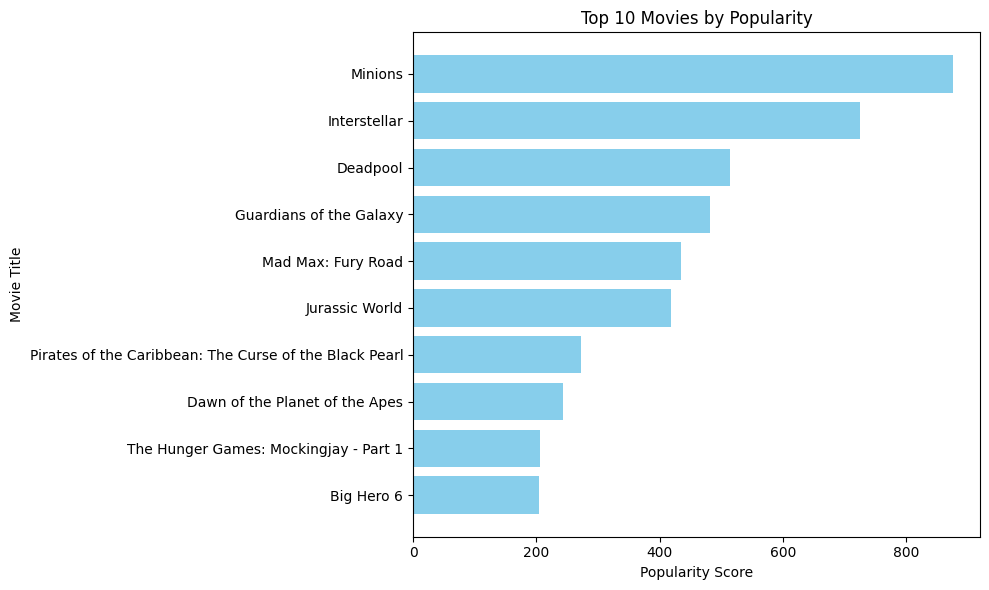

In [35]:
import matplotlib.pyplot as plt

top10 = movies.sort_values(
    by='popularity', ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top10['title'],
    top10['popularity'],
    color='skyblue'
)

plt.xlabel("Popularity Score")
plt.ylabel("Movie Title")
plt.title("Top 10 Movies by Popularity")
plt.gca().invert_yaxis()  # highest popularity on top
plt.tight_layout()

plt.show()


In [36]:
#DESCRIPTIVE STATISTICS


print("Average Revenue:", movies['revenue'].mean())
print("Median Revenue:", movies['revenue'].median())
print("Minimum Revenue:", movies['revenue'].min())
print("Maximum Revenue:", movies['revenue'].max())
print("Range of Revenue:", movies['revenue'].max() - movies['revenue'].min())
print("Standard Deviation of Revenue:", movies['revenue'].std())
print("Average Budget:", movies['budget'].mean())
print("Average Runtime:", movies['runtime'].mean())

Average Revenue: 524307090.565
Median Revenue: 458483489.0
Minimum Revenue: 6000000
Maximum Revenue: 2787965087
Range of Revenue: 2781965087
Standard Deviation of Revenue: 384403804.75880027
Average Budget: 106159976.87
Average Runtime: 126.0


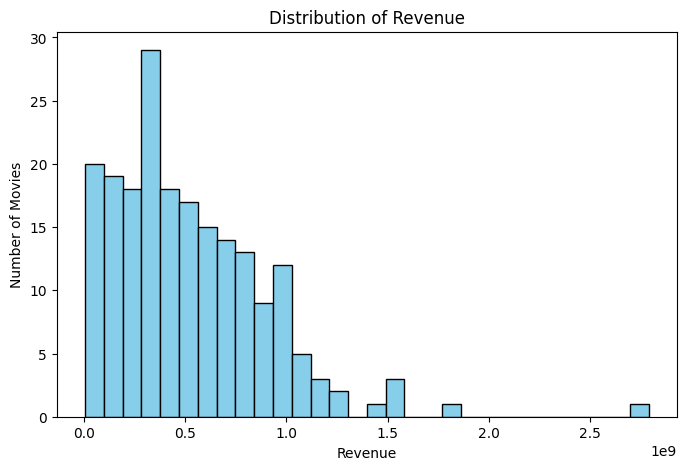

In [37]:
#DATA VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

# 19. Histogram for Revenue
plt.figure(figsize=(8, 5))
plt.hist(movies['revenue'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Movies")
plt.show()

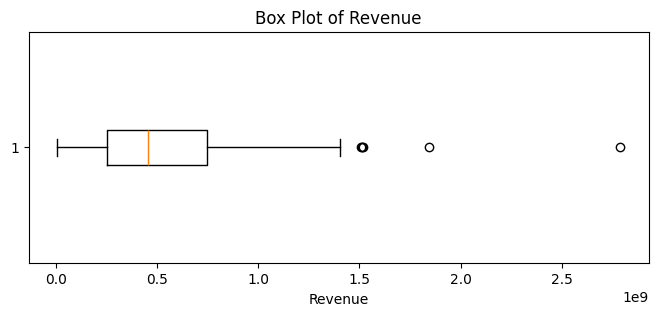

In [38]:
#Box Plot for Revenue (outliers)
plt.figure(figsize=(8, 3))
plt.boxplot(movies['revenue'], vert=False)
plt.title("Box Plot of Revenue")
plt.xlabel("Revenue")
plt.show()

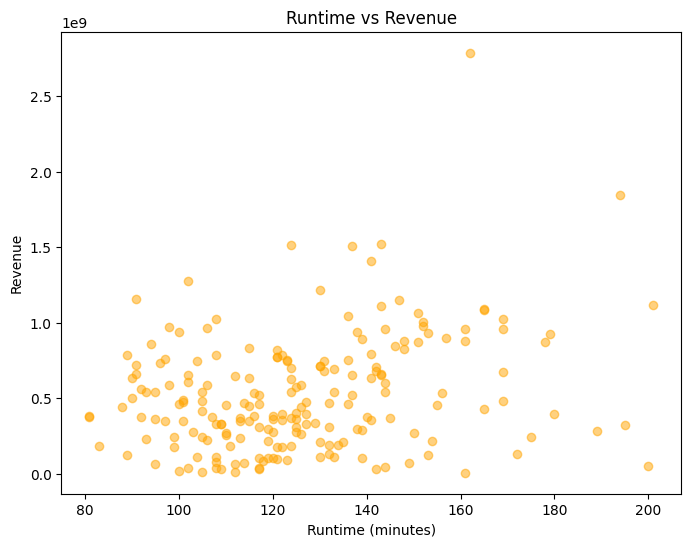

In [45]:
#Scatter Plot - Runtime vs Revenue
plt.figure(figsize=(8, 6))
plt.scatter(movies['runtime'], movies['revenue'], alpha=0.5, color='orange')
plt.title("Runtime vs Revenue")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Revenue")
plt.show()

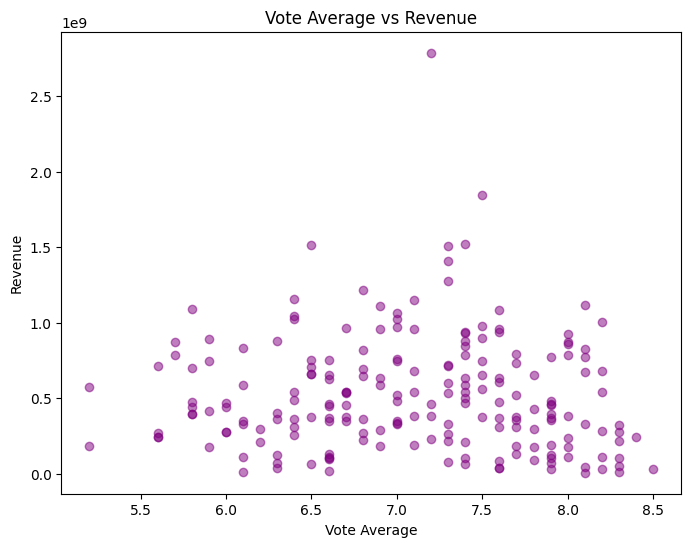

In [46]:
#Scatter Plot - Vote_average vs Revenue
plt.figure(figsize=(8, 6))
plt.scatter(movies['vote_average'], movies['revenue'], alpha=0.5, color='purple')
plt.title("Vote Average vs Revenue")
plt.xlabel("Vote Average")
plt.ylabel("Revenue")
plt.show()

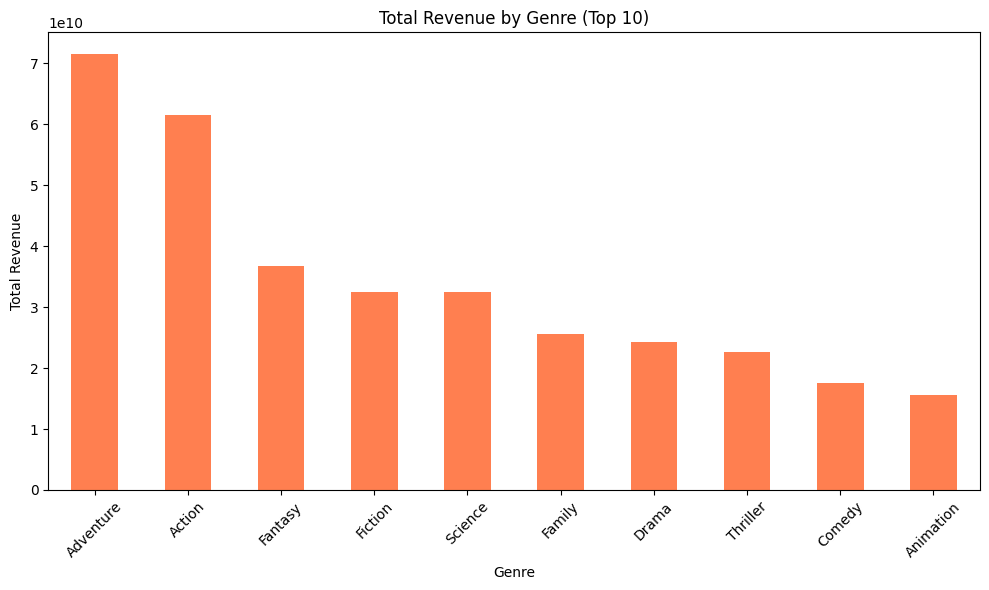

In [47]:
#Bar Chart - Revenue by Genre (top genre by revenue)
genre_revenue = {}
for genres_str, rev in zip(movies['genres'], movies['revenue']):
    for genre in str(genres_str).split():
        genre_revenue[genre] = genre_revenue.get(genre, 0) + rev

genre_series = pd.Series(genre_revenue).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
genre_series.plot(kind='bar', color='coral')
plt.title("Total Revenue by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

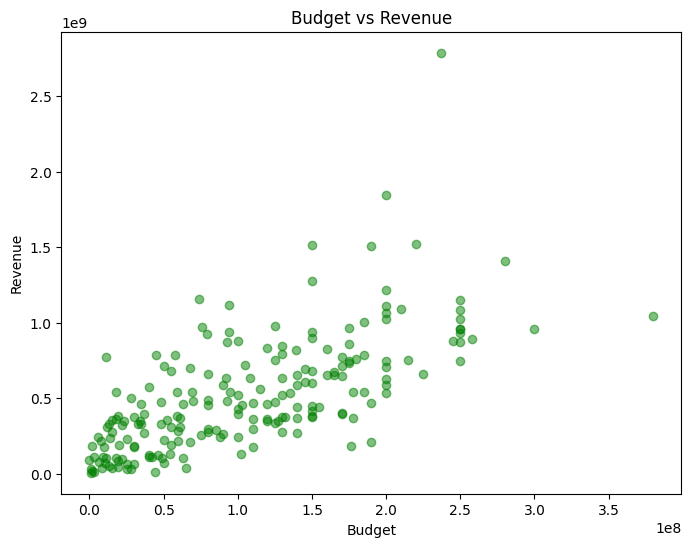

In [48]:
#Scatter Plot - Budget vs Revenue
plt.figure(figsize=(8, 6))
plt.scatter(movies['budget'], movies['revenue'], alpha=0.5, color='green')
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()


Correlation Matrix:
                budget  vote_average   runtime  vote_count   revenue
budget        1.000000     -0.311950  0.235517    0.314653  0.675653
vote_average -0.311950      1.000000  0.321693    0.443661 -0.047807
runtime       0.235517      0.321693  1.000000    0.382237  0.267257
vote_count    0.314653      0.443661  0.382237    1.000000  0.522911
revenue       0.675653     -0.047807  0.267257    0.522911  1.000000


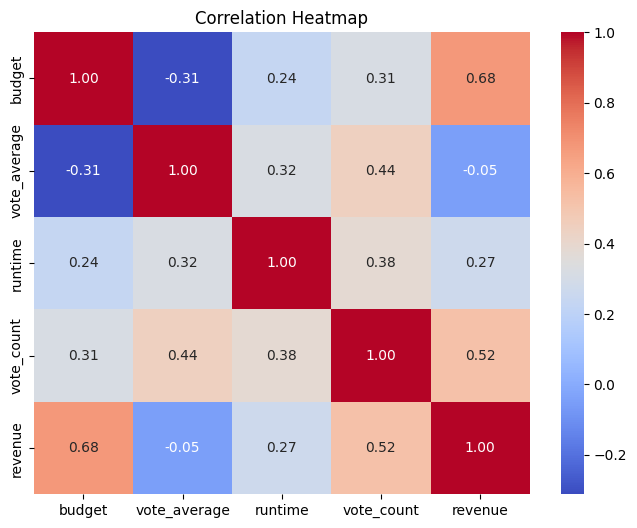

In [49]:
#CORRELATION

corr_columns = ['budget', 'vote_average', 'runtime', 'vote_count', 'revenue']
correlation_matrix = movies[corr_columns].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [51]:
#  Strongest relationship with Revenue
revenue_corr = correlation_matrix['revenue'].drop('revenue').sort_values(
    ascending=False
)
print("\nStrongest correlations with Revenue:")
print(revenue_corr)


Strongest correlations with Revenue:
budget          0.675653
vote_count      0.522911
runtime         0.267257
vote_average   -0.047807
Name: revenue, dtype: float64


In [52]:
#REGRESSION


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 29. Input features and 30. target variable
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count']
X = movies[features]
y = movies['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
#  Train the model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\nModel R2 Score:", r2_score(y_test, y_pred))
print("Model MAE:", mean_absolute_error(y_test, y_pred))


Model R2 Score: 0.49791828998750876
Model MAE: 209250649.51143777


In [54]:
#  Create a new "order" (movie) with your own feature values
new_movie = pd.DataFrame({
    'budget': [50000000],
    'popularity': [80],
    'runtime': [120],
    'vote_average': [7.2],
    'vote_count': [3000]
})

In [55]:
# Predict expected Revenue
predicted_revenue = model.predict(new_movie)
print("\nPredicted Revenue for new movie:", predicted_revenue[0])



Predicted Revenue for new movie: 273513774.8154452
